# Where the Water Flows -- Glacier de Bonne Pierre

In [1]:
using Pkg; Pkg.activate("/scratch-1/cogier/hydraulic_barriers/")
using Rasters
using Shapefile
using WhereTheWaterFlowsSubglacially, WhereTheWaterFlows
const WWFS = WhereTheWaterFlowsSubglacially
const WWF = WhereTheWaterFlows
#using ArchGDAL
#using MAT
using Plots
#using GlacioTools
#Pkg.status()



  Activating project at `/scratch-1/cogier/hydraulic_barriers`


In [26]:
datadir = "/scratch-1/cogier/data/DEM"
#include("helper_functions.jl")

"/scratch-1/cogier/data/DEM"

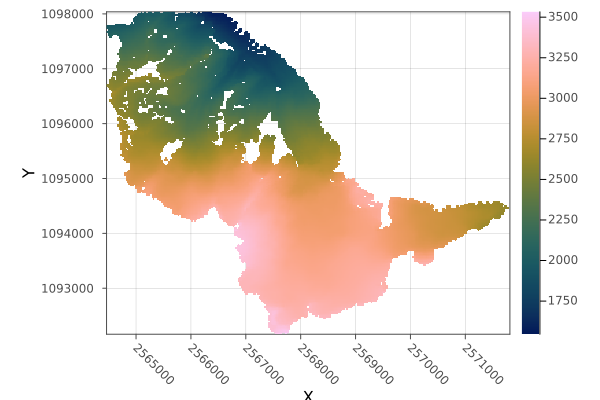

In [ ]:
# TRIENT
# Findelen surface in 1931
surf_trient_1928 = Raster(joinpath(datadir,"alps/B90-02_trient_19280000_dsm_25m_lv95_ln02.tif"));
Plots.heatmap(surf_trient_1928)

In [ ]:
# extract bedrock from Grab et al 2021
#geom_select("Trient","B90-02", datadir, do_save=true); 
trient_BedElev_2016 = Raster(joinpath(datadir,"alps/Trient_BedElev_cr.tif"));
Plots.heatmap(trient_BedElev_2016);

In [ ]:

# Merge bed rock of 2016 and surface elevation 2019 -> that makes glacier free topography ONLY for findelen though
all_bed_trient = mosaic(first, trient_BedElev_2016, all_surf_2019);  # in case of overlap, we take the values of all_bed first

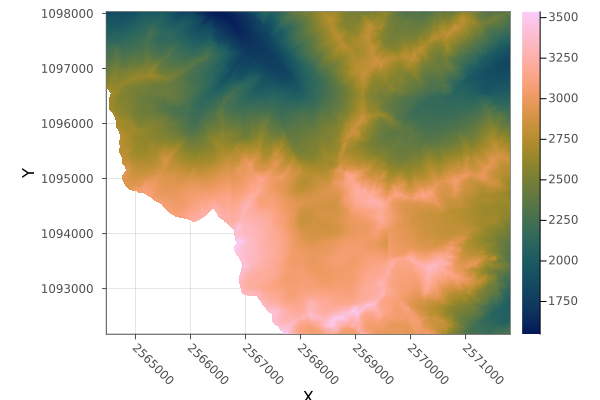

In [ ]:
#crop surface elevation to bed data to match dimension (before substracting)
bed_trient_1928_cr = crop(all_bed_trient; to=surf_trient_1928);
bed_trient_1928_cr[bed_trient_1928_cr .< 0] .= NaN; #missing values in all_surf is -3.4028235e38
Plots.heatmap(bed_trient_1928_cr)


In [ ]:
bed_trient_1928_cr_resamp = resample(bed_trient_1928_cr, to=surf_trient_1928);

In [ ]:
## run WWFS and save data

# with gamma = -0.31 (Rothlisberger constant = stream deflection)
(area_r, slen_r, dir, nout_r, nin_r, pits_r, c_r, bnds_r),
         (sc_locs_r, kappas_r, diro_r, phi_r),
         (lakes_r, lakes_free_surf_r),
         sinkout_r = WWFS.waterflows_subglacial(surf_trient_1928[:,:,1], bed_trient_1928_cr_resamp[:, :, 1], gamma=[0,WWFS.GAMMA][2], bnd_as_pits=true, drain_pits=true);

write(joinpath(datadir,"WWFS_output","area_r_trient1928.tif"),area_r);
write(joinpath(datadir,"WWFS_output","lakes_r_trient1928.tif"),lakes_r);
write(joinpath(datadir,"WWFS_output","phi_r_trient1928.tif"),phi_r); # shreve potential

         

"/scratch-3/cogier/2023_WWF_WPOFs/mydata/WWFS_output/phi_r_trient1928.tif"

2

In [ ]:
#Argentières
"""
filebed = matopen(joinpath(datadir,"alps/DEMbed_IncludingSeracs_20m_LambertIIEtendu.mat"));
filesurf = matopen(joinpath(datadir,"alps/DEMsurf_2018_NotIncludingSeracs_2m_LambertIIEtendu.mat")); # bed and surf are not the same size !
bedx = read(filebed, "X")[1,:] #longitude, dx=20m
bedy = read(filebed, "Y")[:,1] #latitude, dx=20m
bedz = read(filebed, "Zbed_christian");
surfx = read(filesurf, "X")[1,:] #longitude, dx=20m
surf = read(filesurf, "Y")[:,1] #latitude, dx=20m
surfz = read(filesurf, "Zsurf");
"""



"filebed = matopen(joinpath(datadir,\"alps/DEMbed_IncludingSeracs_20m_LambertIIEtendu.mat\"));\nfilesurf = matopen(joinpath(datadir,\"alps/DEMsurf_2018_NotIncludingSeracs_2m_LambertIIEtendu.mat\")); # bed and surf are not the same size !\nbedx = read(filebed, \"X\")[1,:] #longitude, dx=20m\nbedy = read(filebed, \"Y\")[:,1] #latitude, dx=20m\nbedz = read(filebed, \"Zbed_christian\");\nsurfx = read(filesurf, \"X\")[1,:] #longitude, dx=20m\nsurf = read(filesurf, \"Y\")[:,1] #latitude, dx=20m\nsurfz = read(filesurf, \"Zsurf\");\n"

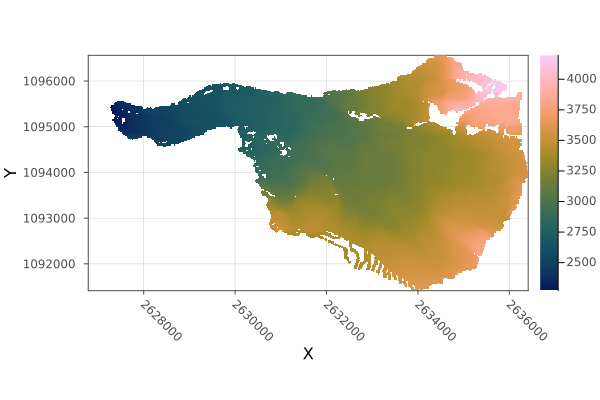

In [ ]:
# Findelen surface in 1931
surf_findelen_1931 = Raster(joinpath(datadir,"alps/findelen_1931_25m_lv95.tif"));
Plots.heatmap(surf_findelen_1931)

In [ ]:
# bedrock of findelen 2016
#geom_select("Findelen","B56-03", datadir, do_save=true); 
findelen_BedElev_2016 = Raster(joinpath(datadir,"alps/Findelen_BedElev_cr.tif"));

In [ ]:
# Merge bed rock of 2016 and surface elevation 2019 -> that makes glacier free topography ONLY for findelen though
all_bed_findelen = mosaic(first, findelen_BedElev_2016, all_surf_2019);  # in case of overlap, we take the values of all_bed first

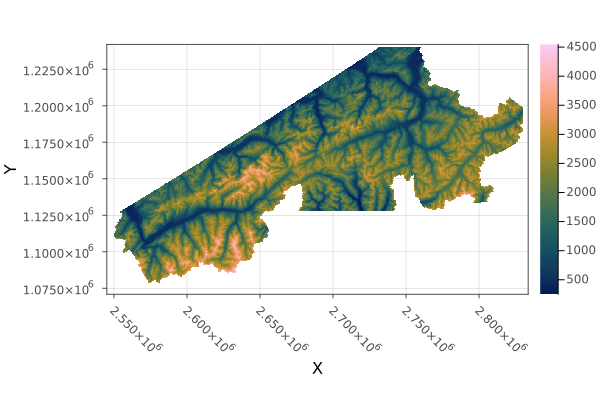

In [ ]:
Plots.heatmap(all_bed_findelen)

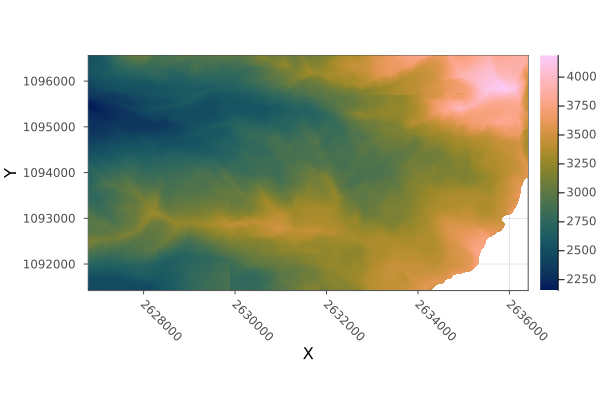

In [ ]:
#crop surface elevation to bed data to match dimension (before substracting)
bed_findelen_1931_cr = crop(all_bed_findelen; to=surf_findelen_1931);
bed_findelen_1931_cr[bed_findelen_1931_cr .< 0] .= NaN; #missing values in all_surf is -3.4028235e38
Plots.heatmap(bed_findelen_1931_cr)

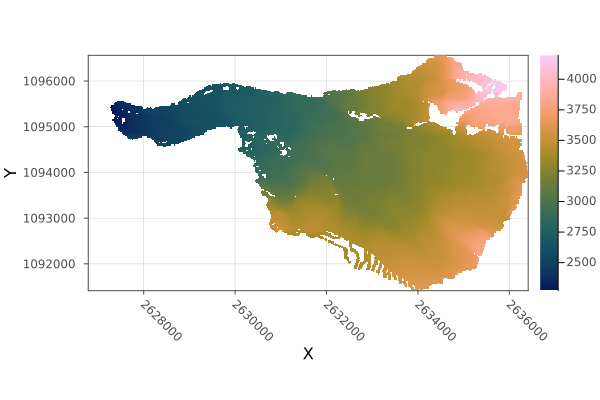

In [ ]:
Plots.heatmap(surf_findelen_1931)

In [ ]:
bed_findelen_1931_cr_resamp = resample(bed_findelen_1931_cr, to=surf_findelen_1931)

385×206×1 Raster{Float32,3} with dimensions: 
  X Projected{Float64} LinRange{Float64}(2.62679e6, 2.63639e6, 385) ForwardOrdered Regular Intervals crs: WellKnownText,
  Y Projected{Float64} LinRange{Float64}(1.09654e6, 1.09141e6, 206) ReverseOrdered Regular Intervals crs: WellKnownText,
  Band Categorical{Int64} 1:1 ForwardOrdered
extent: Extent(X = (2.6267875e6, 2.6364125e6), Y = (1.0914125e6, 1.0965625e6), Band = (1, 1))missingval: -3.4028235e38
crs: PROJCS["CH1903+ / LV95",GEOGCS["CH1903+",DATUM["CH1903+",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6150"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4150"]],PROJECTION["Hotine_Oblique_Mercator_Azimuth_Center"],PARAMETER["latitude_of_center",46.9524055555556],PARAMETER["longitude_of_center",7.43958333333333],PARAMETER["azimuth",90],PARAMETER["rectified_grid_angle",90],PARAMETER["scale_factor",1],PARAMETER["fal

In [ ]:
size(surf_findelen_1931) == size(bed_findelen_1931_cr_resamp)

true

In [ ]:
write(joinpath(datadir,"alps","Findelen_bed_1931_25m.tif"),bed_findelen_1931_cr_resamp);

In [ ]:
# with gamma = -0.31 (Rothlisberger constant = stream deflection)
(area_r, slen_r, dir, nout_r, nin_r, pits_r, c_r, bnds_r),
         (sc_locs_r, kappas_r, diro_r, phi_r),
         (lakes_r, lakes_free_surf_r),
         sinkout_r = WWFS.waterflows_subglacial(surf_findelen_1931[:,:,1], bed_findelen_1931_cr_resamp[:, :, 1], gamma=[0,WWFS.GAMMA][2], bnd_as_pits=true, drain_pits=true);

In [ ]:
write(joinpath(datadir,"WWFS_output","area_r_findelen1931.tif"),area_r);
write(joinpath(datadir,"WWFS_output","lakes_r_findelen1931.tif"),lakes_r);
write(joinpath(datadir,"WWFS_output","phi_r_findelen1931.tif"),phi_r); # shreve potential
